# Data Audit and Semantic Contract

## Why this notebook exists

Before building the agent, we need to know which numbers it can use safely. This notebook checks what each file contains, whether rows are unique, how missing and zero values should be interpreted, and whether overlapping files agree.

The result is a proposed contract for the agent: which source answers each question, how metrics are calculated, and when the agent must show a caveat.

**Scope:** this notebook evaluates data structure and trustworthiness. It does not yet make claims about business performance. The app will not run this notebook; approved logic will move into reusable Python modules and a prebuilt SQLite database.

## 1. Questions we need to answer

1. What does one row in each file represent?
2. Are rows complete and unique at that level?
3. When two files contain similar metrics, do their totals agree?
4. Which source should answer each type of business question?
5. What rules should prevent the agent from producing misleading comparisons?

A source is ready for the agent when we understand its row structure, aggregation rules, and limits. Similar-looking measures remain separate unless the reconciliation test supports combining them.

## 2. Setup and reproducibility

In [1]:
from pathlib import Path
import platform
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "Case Study Data "
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"

print({
    "python": platform.python_version(),
    "pandas": metadata.version("pandas"),
    "numpy": metadata.version("numpy"),
    "matplotlib": metadata.version("matplotlib"),
    "seaborn": metadata.version("seaborn"),
})

{'python': '3.14.6', 'pandas': '3.0.3', 'numpy': '2.4.1', 'matplotlib': '3.10.8', 'seaborn': '0.13.2'}


In [2]:
SOURCES = {
    "digital_commerce": {
        "file": "Digital Daily-Country-State level - Transformed (v3).xlsx",
        "date": "ty_order_date",
        "grain": ["ty_order_date", "country", "state_code", "state"],
        "dimensions": ["country", "state_code", "state"],
        "measures": [
            "ty_total_revenue", "ly_total_revenue", "ty_total_units", "ly_total_units",
            "ty_total_orders", "ly_total_orders", "ty_new_customers", "ly_new_customers",
            "ty_sessions", "ly_sessions",
        ],
    },
    "digital_marketing": {
        "file": "Digital-DailyxStatexChannelxDevice - Transformed (Top20) - v3.xlsx",
        "date": "ty_date_dt",
        "grain": ["ty_date_dt", "channel", "country_name", "session_state", "device_category"],
        "dimensions": ["channel", "country_name", "session_state", "device_category"],
        "measures": [
            "ty_ga_revenue", "ly_ga_revenue", "ty_sessions", "ly_sessions",
            "ty_total_orders", "ly_total_orders", "ty_digital_customers_acquired",
            "ly_digital_customers_acquired", "ty_qty_ordered", "ly_qty_ordered",
        ],
    },
    "retail_store": {
        "file": "Retail - Daily & Store Level - Transformed (v3).xlsx",
        "date": "day",
        "grain": ["day", "store_id"],
        "dimensions": ["store_id", "opening_date"],
        "measures": [
            "ty_net_sales", "ty_traffic", "ty_orders", "ty_units",
            "ly_net_sales", "ly_traffic", "ly_orders", "ly_units",
        ],
    },
    "retail_category": {
        "file": "Retail Product Category - Transformed (v3).xlsx",
        "date": "day",
        "grain": ["day", "store_id", "product_category"],
        "dimensions": ["store_id", "product_category", "opening_date"],
        "measures": ["ty_net_sales", "ty_units", "ly_net_sales", "ly_units"],
    },
}

frames = {
    name: pd.read_excel(DATA_DIR / cfg["file"])
    for name, cfg in SOURCES.items()
}

for name, df in frames.items():
    df[SOURCES[name]["date"]] = pd.to_datetime(df[SOURCES[name]["date"]])

print(f"Loaded {len(frames):,} sources and {sum(len(df) for df in frames.values()):,} rows.")

Loaded 4 sources and 293,171 rows.


## 3. What files do we have?

The instructions describe two business areas, Digital and Retail, while the delivery contains four files. Each area has a summary-style source and a more detailed source. We first inspect them separately rather than assuming they can be joined.

In [3]:
inventory_rows = []
for name, df in frames.items():
    cfg = SOURCES[name]
    date = cfg["date"]
    observed_dates = pd.DatetimeIndex(df[date].dropna().unique()).sort_values()
    expected_dates = pd.date_range(observed_dates.min(), observed_dates.max(), freq="D")
    inventory_rows.append({
        "source": name,
        "rows": len(df),
        "columns": len(df.columns),
        "date_min": observed_dates.min().date(),
        "date_max": observed_dates.max().date(),
        "distinct_dates": len(observed_dates),
        "expected_daily_dates": len(expected_dates),
        "continuous_daily_coverage": observed_dates.equals(expected_dates),
        "declared_grain": " × ".join(cfg["grain"]),
    })

inventory = pd.DataFrame(inventory_rows).set_index("source")
display(inventory)

,rows,columns,date_min,date_max,distinct_dates,expected_daily_dates,continuous_daily_coverage,declared_grain
source,,,,,,,,
digital_commerce,24817,16,2026-05-03,2026-07-04,63,63,True,ty_order_date × country × state_code × state
digital_marketing,153031,15,2026-05-03,2026-07-04,63,63,True,ty_date_dt × channel × country_name × session_state × device_category
retail_store,11592,11,2026-05-03,2026-07-04,63,63,True,day × store_id
retail_category,103731,8,2026-05-03,2026-07-04,63,63,True,day × store_id × product_category


In [4]:
# Dimension cardinality and explicit unknown-value coverage.
dimension_rows = []
for name, df in frames.items():
    for column in SOURCES[name]["dimensions"]:
        values = df[column]
        unknown = values.astype("string").str.lower().isin(["(not-set)", "unknown", "not set"])
        dimension_rows.append({
            "source": name,
            "dimension": column,
            "distinct_non_null": values.nunique(dropna=True),
            "missing_rows_pct": 100 * values.isna().mean(),
            "explicit_unknown_rows_pct": 100 * unknown.mean(),
            "sample_values": ", ".join(values.dropna().astype(str).drop_duplicates().head(5)),
        })

dimension_profile = pd.DataFrame(dimension_rows)
display(dimension_profile)

,source,dimension,distinct_non_null,missing_rows_pct,explicit_unknown_rows_pct,sample_values
0,digital_commerce,country,34,13.193,0.000,"Spain, Canada, Australia, Romania, Italy"
1,digital_commerce,state_code,617,13.559,0.000,"A, AB, ACT, AG, AGS"
2,digital_commerce,state,746,13.193,0.000,"Alicante, Alberta, Albacete, Australian Capital Territory, ArgeÈ™"
3,digital_marketing,channel,16,0.000,11.438,"(not-set), affiliates, alo moves, direct, email"
4,digital_marketing,country_name,20,0.000,0.000,"australia, canada, colombia, france, germany"
5,digital_marketing,session_state,54,0.000,29.587,"(not-set), alabama, alaska, arizona, arkansas"
6,digital_marketing,device_category,4,0.000,5.532,"(not-set), app, desktop, mobile"
7,retail_store,store_id,183,0.000,0.000,"10069, 10085, 10130, 10102, 10110"
8,retail_store,opening_date,122,4.348,0.000,"2023-09-15, 2024-09-05, 2025-11-27, 2024-06-13, 2024-11-14"
9,retail_category,store_id,174,0.000,0.000,"10006, 10037, 50084, 10173, 10093"


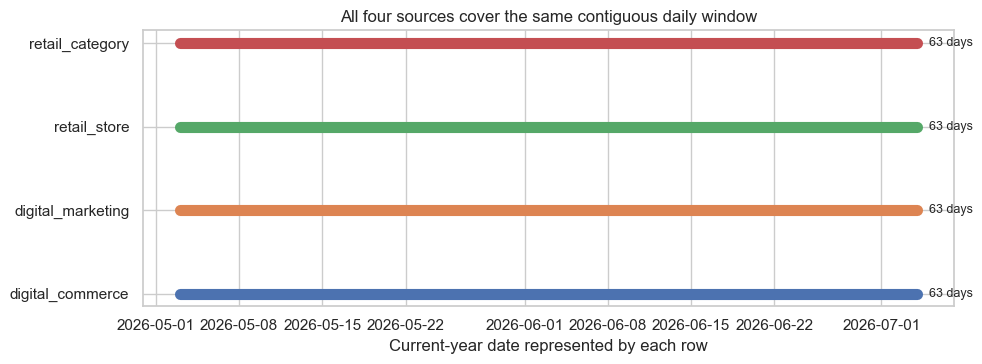

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for y, row in enumerate(inventory.reset_index().itertuples()):
    start = pd.Timestamp(row.date_min)
    end = pd.Timestamp(row.date_max)
    ax.plot([start, end], [y, y], linewidth=8, solid_capstyle="round")
    ax.text(end + pd.Timedelta(days=1), y, f"{row.distinct_dates} days", va="center", fontsize=9)
ax.set_yticks(range(len(inventory)))
ax.set_yticklabels(inventory.index)
ax.set_title("All four sources cover the same contiguous daily window")
ax.set_xlabel("Current-year date represented by each row")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### What this tells us

- All four files cover the same 63 consecutive days, so they can use the same date filters.
- The Digital files answer different questions: one is organized around commerce and geography, while the other is organized around GA, channels, and devices.
- The category file covers fewer stores than the store-level Retail file, so category results cannot be presented as full Retail coverage.

## 4. Does one row mean what we expect?

The **grain** is the set of fields that should identify one row. For example, if a table is daily by store, `date + store` should appear only once. Repeated keys can cause double counting or indicate that a supposedly available dimension is actually unknown.

This test counts both the rows involved in repeated keys and the number of repeated key groups. Two rows for the same date and store count as two affected rows but one repeated group.

In [6]:
grain_rows = []
grain_exceptions = {}
for name, df in frames.items():
    grain = SOURCES[name]["grain"]
    duplicate_mask = df.duplicated(grain, keep=False)
    duplicate_groups = (
        df.loc[duplicate_mask]
          .groupby(grain, dropna=False)
          .size()
          .reset_index(name="rows_in_group")
    )
    grain_rows.append({
        "source": name,
        "one_row_should_represent": " × ".join(grain),
        "rows_in_repeated_keys": int(duplicate_mask.sum()),
        "repeated_key_groups": len(duplicate_groups),
        "passes_uniqueness_check": not duplicate_mask.any(),
    })
    grain_exceptions[name] = df.loc[duplicate_mask].copy()

grain_audit = pd.DataFrame(grain_rows).set_index("source")
display(grain_audit)

,one_row_should_represent,rows_in_repeated_keys,repeated_key_groups,passes_uniqueness_check
source,,,,
digital_commerce,ty_order_date × country × state_code × state,3274,63,False
digital_marketing,ty_date_dt × channel × country_name × session_state × device_category,0,0,True
retail_store,day × store_id,126,63,False
retail_category,day × store_id × product_category,0,0,True


In [7]:
# Explain the repeated-key patterns without printing raw business rows.
exception_summary = []
for name, exceptions in grain_exceptions.items():
    if exceptions.empty:
        exception_summary.append({"source": name, "what_we_found": "No repeated keys"})
        continue
    cfg = SOURCES[name]
    missing_key_fields = [c for c in cfg["grain"] if exceptions[c].isna().any()]
    zero_only = bool((exceptions[cfg["measures"]].fillna(0) == 0).all(axis=None))
    store_ids = exceptions["store_id"].unique().tolist() if "store_id" in exceptions else []
    if name == "digital_commerce":
        finding = "Multiple rows per day have no country or state; measures are not all zero"
    elif name == "retail_store" and store_ids == [0] and zero_only:
        finding = "Two all-zero store_id=0 placeholder rows appear on each day"
    else:
        finding = f"missing key fields={missing_key_fields}; store IDs={store_ids[:5]}; all measures zero={zero_only}"
    exception_summary.append({"source": name, "what_we_found": finding})

display(pd.DataFrame(exception_summary).set_index("source"))

,what_we_found
source,
digital_commerce,Multiple rows per day have no country or state; measures are not all zero
digital_marketing,No repeated keys
retail_store,Two all-zero store_id=0 placeholder rows appear on each day
retail_category,No repeated keys


### What we should do

- **Digital commerce:** keep the rows with missing geography because they contain real measures. Group them under `Unknown` for totals, but do not use them for state-level claims.
- **Digital marketing:** no repeated keys were found at its detailed row definition.
- **Retail store:** remove the duplicated `store_id = 0` rows because they are confirmed all-zero placeholders, not stores.
- **Retail category:** no repeated keys were found at date × store × category, although its totals still need the separate reconciliation test in Section 6.

## 5. Which values need context?

This section does **not** label every zero, missing value, or negative value as bad data. It identifies values for which the agent needs a clear interpretation rule.

For example, zero LY sales may be correct when a store was not open last year. A negative sale may be a return. A missing state still contributes to total revenue but cannot support a state-level explanation.

In [8]:
quality_rows = []
field_quality_rows = []
for name, df in frames.items():
    cfg = SOURCES[name]
    measures = cfg["measures"]
    dimensions = cfg["dimensions"]
    duplicate_mask = df.duplicated(cfg["grain"], keep=False)
    measure_cells = df[measures]
    dim_cells = df[dimensions]
    explicit_unknown = dim_cells.astype("string").apply(
        lambda s: s.str.lower().isin(["(not-set)", "unknown", "not set"])
    )
    quality_rows.append({
        "source": name,
        "missing dimensions %": 100 * dim_cells.isna().to_numpy().mean(),
        "explicit unknowns %": 100 * explicit_unknown.to_numpy().mean(),
        "zero measures %": 100 * (measure_cells == 0).to_numpy().mean(),
        "negative measures %": 100 * (measure_cells < 0).to_numpy().mean(),
        "rows in repeated keys %": 100 * duplicate_mask.mean(),
    })
    for field in dimensions + measures:
        series = df[field]
        field_quality_rows.append({
            "source": name,
            "field": field,
            "missing %": 100 * series.isna().mean(),
            "zero %": 100 * (series.eq(0).mean() if pd.api.types.is_numeric_dtype(series) else 0),
            "negative %": 100 * (series.lt(0).mean() if pd.api.types.is_numeric_dtype(series) else 0),
        })

quality_summary = pd.DataFrame(quality_rows).set_index("source")
field_quality = pd.DataFrame(field_quality_rows)
display(quality_summary)

,missing dimensions %,explicit unknowns %,zero measures %,negative measures %,rows in repeated keys %
source,,,,,
digital_commerce,13.315,0.000,38.001,0.000,13.193
digital_marketing,0.000,11.639,40.369,0.000,0.000
retail_store,2.174,0.000,23.977,0.127,1.087
retail_category,1.924,0.000,11.194,0.798,0.000


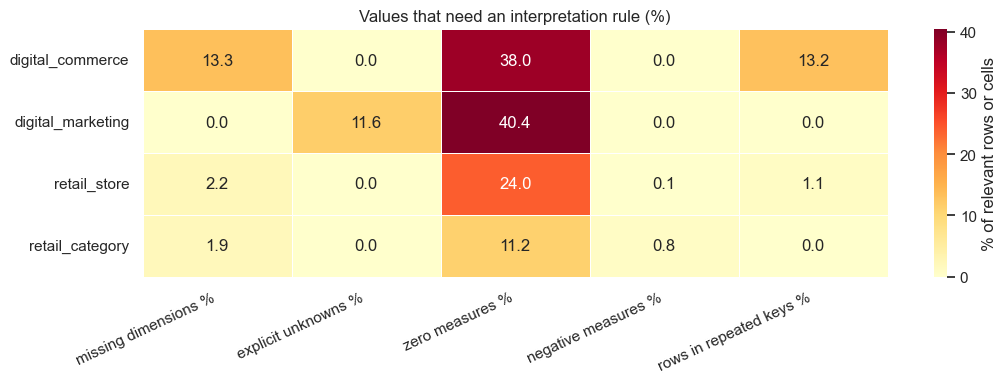

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    quality_summary,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={"label": "% of relevant rows or cells"},
    ax=ax,
)
ax.set_title("Values that need an interpretation rule (%)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# List fields that contain at least one value requiring interpretation.
fields_needing_context = field_quality[
    (field_quality[["missing %", "zero %", "negative %"]] > 0).any(axis=1)
].sort_values(["source", "field"])
display(fields_needing_context)

,source,field,missing %,zero %,negative %
0,digital_commerce,country,13.193,0.000,0.000
10,digital_commerce,ly_new_customers,0.000,64.097,0.000
12,digital_commerce,ly_sessions,0.000,71.499,0.000
8,digital_commerce,ly_total_orders,0.000,56.199,0.000
4,digital_commerce,ly_total_revenue,0.000,56.199,0.000
6,digital_commerce,ly_total_units,0.000,56.199,0.000
2,digital_commerce,state,13.193,0.000,0.000
1,digital_commerce,state_code,13.559,0.000,0.000
9,digital_commerce,ty_new_customers,0.000,23.033,0.000
11,digital_commerce,ty_sessions,0.000,52.778,0.000


### Are the Retail LY zeros explained by new stores?

For rows where all four LY measures are zero, we compare the opening date with the approximate prior-year date. This separates expected new-store baselines from existing stores that had no LY activity. Because the source supplies paired LY values rather than exact LY dates, this is a practical classification rather than a formal fiscal-calendar test.

,rows,distinct_stores,share of no-LY rows %
LY baseline interpretation,,,
Store was not open in LY,3911,66,88.046
Cannot classify: opening date missing,378,6,8.510
Existing store with no LY activity,153,11,3.444


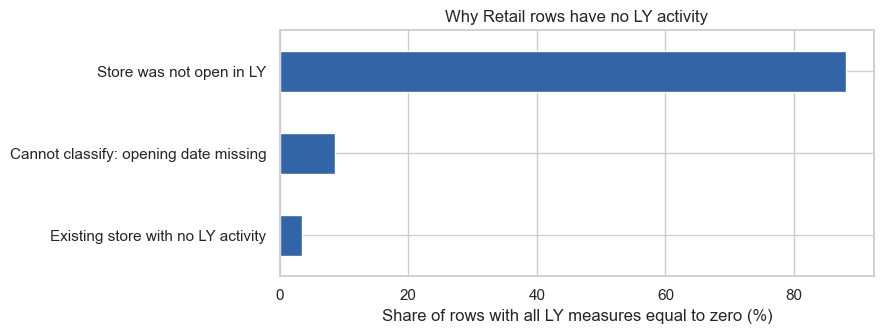

In [11]:
retail = frames["retail_store"].loc[frames["retail_store"]["store_id"].ne(0)].copy()
ly_fields = ["ly_net_sales", "ly_traffic", "ly_orders", "ly_units"]
no_ly_activity = retail[ly_fields].eq(0).all(axis=1)
approximate_ly_date = retail["day"] - pd.DateOffset(years=1)

retail["LY baseline interpretation"] = "Has LY activity"
retail.loc[
    no_ly_activity & retail["opening_date"].notna() & retail["opening_date"].gt(approximate_ly_date),
    "LY baseline interpretation",
] = "Store was not open in LY"
retail.loc[
    no_ly_activity & retail["opening_date"].notna() & retail["opening_date"].le(approximate_ly_date),
    "LY baseline interpretation",
] = "Existing store with no LY activity"
retail.loc[
    no_ly_activity & retail["opening_date"].isna(),
    "LY baseline interpretation",
] = "Cannot classify: opening date missing"

no_ly_summary = (
    retail.loc[no_ly_activity]
    .groupby("LY baseline interpretation")
    .agg(rows=("store_id", "size"), distinct_stores=("store_id", "nunique"))
    .sort_values("rows", ascending=False)
)
no_ly_summary["share of no-LY rows %"] = 100 * no_ly_summary["rows"] / no_ly_summary["rows"].sum()
display(no_ly_summary)

fig, ax = plt.subplots(figsize=(9, 3.5))
no_ly_summary["share of no-LY rows %"].sort_values().plot.barh(ax=ax, color="#3264a8")
ax.set_title("Why Retail rows have no LY activity")
ax.set_xlabel("Share of rows with all LY measures equal to zero (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### What we should do

- Keep legitimate zeros. For totals, a zero contributes zero as expected.
- When LY is zero, do not report an infinite growth rate. Label the record `New / no LY baseline` and use an absolute or week-over-week comparison instead.
- Keep negative Retail sales and units as possible returns until the business confirms their meaning.
- Calculate AOV, conversion, and UPT from summed inputs; do not average row-level rates.
- Return no rate when its denominator is zero.
- Keep the supplied decimal precision for calculations. Because the data is transformed, count-like measures should not be described as raw transaction counts.
- Display missing and `(not-set)` dimensions as `Unknown`, while retaining a quality flag behind the answer.

## 6. Do overlapping files tell the same story?

Two files may both contain a field called revenue without measuring the same thing. We compare totals only after rolling each file up to the same daily level. A consistent gap can indicate different systems or coverage; a very large gap means the measures should not be combined.

In [12]:
def daily_sum(source, columns):
    cfg = SOURCES[source]
    return frames[source].groupby(cfg["date"])[columns].sum().sort_index()

# Commerce-system-style Digital measures versus GA-style Digital measures.
digital_pairs = {
    "TY revenue": ("ty_total_revenue", "ty_ga_revenue"),
    "LY revenue": ("ly_total_revenue", "ly_ga_revenue"),
    "TY orders": ("ty_total_orders", "ty_total_orders"),
    "LY orders": ("ly_total_orders", "ly_total_orders"),
    "TY units": ("ty_total_units", "ty_qty_ordered"),
    "LY units": ("ly_total_units", "ly_qty_ordered"),
    "TY sessions": ("ty_sessions", "ty_sessions"),
    "LY sessions": ("ly_sessions", "ly_sessions"),
    "TY acquired customers": ("ty_new_customers", "ty_digital_customers_acquired"),
    "LY acquired customers": ("ly_new_customers", "ly_digital_customers_acquired"),
}

digital_reconciliation = []
for metric, (commerce_col, marketing_col) in digital_pairs.items():
    commerce = frames["digital_commerce"][commerce_col].sum()
    marketing = frames["digital_marketing"][marketing_col].sum()
    digital_reconciliation.append({
        "metric": metric,
        "digital_commerce_total": commerce,
        "digital_marketing_total": marketing,
        "marketing_vs_commerce_pct": 100 * (marketing / commerce - 1) if commerce else np.nan,
    })

digital_reconciliation = pd.DataFrame(digital_reconciliation).set_index("metric")
display(digital_reconciliation)

,digital_commerce_total,digital_marketing_total,marketing_vs_commerce_pct
metric,,,
TY revenue,"246,021,034.908","226,421,379.897",-7.967
LY revenue,"120,998,963.030","121,022,888.139",0.020
TY orders,"1,456,928.946","1,361,290.081",-6.564
LY orders,"820,256.184","830,680.121",1.271
TY units,"3,924,028.284","3,613,602.547",-7.911
LY units,"2,113,396.934","2,134,993.880",1.022
TY sessions,"52,835,722.313","62,302,665.359",17.918
LY sessions,"32,302,404.453","34,946,134.751",8.184
TY acquired customers,"387,234.639","374,449.295",-3.302


In [13]:
# Store totals versus sums of the category source.
retail_pairs = {
    "TY sales": ("ty_net_sales", "ty_net_sales"),
    "LY sales": ("ly_net_sales", "ly_net_sales"),
    "TY units": ("ty_units", "ty_units"),
    "LY units": ("ly_units", "ly_units"),
}
retail_reconciliation = []
for metric, (store_col, category_col) in retail_pairs.items():
    store_total = frames["retail_store"][store_col].sum()
    category_total = frames["retail_category"][category_col].sum()
    retail_reconciliation.append({
        "metric": metric,
        "retail_store_total": store_total,
        "retail_category_total": category_total,
        "category_vs_store_pct": 100 * (category_total / store_total - 1) if store_total else np.nan,
    })

retail_reconciliation = pd.DataFrame(retail_reconciliation).set_index("metric")
display(retail_reconciliation)

,retail_store_total,retail_category_total,category_vs_store_pct
metric,,,
TY sales,"135,753,118.908","2,215,395,229.965","1,531.930"
LY sales,"72,637,019.208","1,485,150,529.814","1,944.619"
TY units,"4,083,803.968","31,897,774.601",681.080
LY units,"2,417,833.649","23,906,355.330",888.751


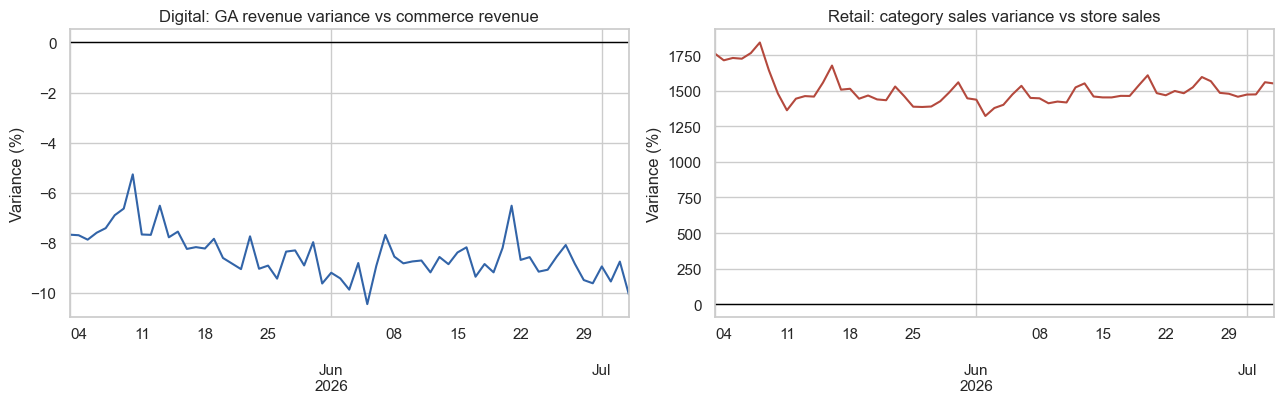

In [14]:
# Daily variance shows whether discrepancies are isolated or systematic.
digital_daily_commerce = daily_sum("digital_commerce", ["ty_total_revenue"])["ty_total_revenue"]
digital_daily_marketing = daily_sum("digital_marketing", ["ty_ga_revenue"])["ty_ga_revenue"]
retail_daily_store = daily_sum("retail_store", ["ty_net_sales"])["ty_net_sales"]
retail_daily_category = daily_sum("retail_category", ["ty_net_sales"])["ty_net_sales"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
(100 * (digital_daily_marketing / digital_daily_commerce - 1)).plot(ax=axes[0], color="#3264a8")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Digital: GA revenue variance vs commerce revenue")
axes[0].set_ylabel("Variance (%)")
axes[0].set_xlabel("")

(100 * (retail_daily_category / retail_daily_store - 1)).plot(ax=axes[1], color="#b4493d")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Retail: category sales variance vs store sales")
axes[1].set_ylabel("Variance (%)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [15]:
reconciliation_diagnostics = pd.DataFrame({
    "comparison": ["Digital GA / commerce TY revenue", "Retail category / store TY sales"],
    "min_daily_ratio": [
        (digital_daily_marketing / digital_daily_commerce).min(),
        (retail_daily_category / retail_daily_store).min(),
    ],
    "median_daily_ratio": [
        (digital_daily_marketing / digital_daily_commerce).median(),
        (retail_daily_category / retail_daily_store).median(),
    ],
    "max_daily_ratio": [
        (digital_daily_marketing / digital_daily_commerce).max(),
        (retail_daily_category / retail_daily_store).max(),
    ],
})
display(reconciliation_diagnostics.set_index("comparison"))

,min_daily_ratio,median_daily_ratio,max_daily_ratio
comparison,,,
Digital GA / commerce TY revenue,0.895,0.914,0.947
Retail category / store TY sales,14.229,15.744,19.396


### What this tells us

- **Digital:** GA revenue and orders are lower than commerce totals in TY even though GA sessions are higher, while AOV is relatively close. This points to sessions and conversion as the main area of disagreement. It could reflect lower-quality traffic, but it could also reflect a measurement gap caused by market launches, incomplete ecommerce tagging, consent behavior, bot filtering, country coverage, or attribution changes. The data does not prove which explanation is correct.
- **Retail:** category sales are roughly 14–19 times store-level sales by day. Missing hierarchy fields could mean that parent and child categories or overlapping tags are being summed together. However, individual categories can also exceed an entire store's reported sales, so hierarchy double counting alone is not proven; different extract logic, scope, currency, or transformation may also be involved.
- **Combined revenue:** Digital uses total revenue while Retail uses net sales, and the files do not state currency treatment. We should not present one company-wide revenue number without those definitions.

### Hypotheses to validate with additional data

| Area | Working hypothesis | What would validate it |
|---|---|---|
| Digital measurement | New markets or tracking changes created a widening difference between sessions and recorded ecommerce outcomes | Market-launch calendar, GA implementation history, ecommerce-event QA, consent rates, bot filtering, and reconciliation by country and device |
| Retail category | Missing hierarchy or rollup markers may cause non-additive category totals | Category ID, parent ID, hierarchy level, leaf/rollup flag, product mapping, transaction lines, source query, currency, and metric definitions |

These are investigation hypotheses, not business conclusions. Until validated, Digital sources remain separately labeled and Retail category dollars remain unavailable for executive attribution.

## 7. What can the agent answer safely?

The table below turns available columns into reporting rules:

- **Canonical:** suitable for executive reporting.
- **Diagnostic:** useful within a clearly labeled source context, such as GA channel analysis.
- **Blocked:** not used until a reconciliation or definition problem is resolved.

A metric can only be filtered by dimensions available in the same source. This prevents invalid joins, such as assigning store traffic to a Digital channel.

In [16]:
metric_contract = pd.DataFrame([
    ["Digital commerce", "Revenue", "digital_commerce", "SUM(ty_total_revenue)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "Orders", "digital_commerce", "SUM(ty_total_orders)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "Units", "digital_commerce", "SUM(ty_total_units)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "Acquired customers", "digital_commerce", "SUM(ty_new_customers)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "AOV", "digital_commerce", "SUM(revenue) / NULLIF(SUM(orders), 0)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "UPT", "digital_commerce", "SUM(units) / NULLIF(SUM(orders), 0)", "date, fiscal period, country, state", "Canonical"],
    ["Digital commerce", "Conversion rate", "digital_commerce", "SUM(orders) / NULLIF(SUM(sessions), 0)", "date, fiscal period, country, state", "Canonical with coverage caveat"],
    ["Digital marketing", "GA-attributed revenue", "digital_marketing", "SUM(ty_ga_revenue)", "date, channel, country, session state, device", "Diagnostic"],
    ["Digital marketing", "Sessions", "digital_marketing", "SUM(ty_sessions)", "date, channel, country, session state, device", "Diagnostic"],
    ["Digital marketing", "Tracked orders", "digital_marketing", "SUM(ty_total_orders)", "date, channel, country, session state, device", "Diagnostic"],
    ["Digital marketing", "Conversion rate", "digital_marketing", "SUM(orders) / NULLIF(SUM(sessions), 0)", "date, channel, country, session state, device", "Diagnostic"],
    ["Digital marketing", "AOV", "digital_marketing", "SUM(revenue) / NULLIF(SUM(orders), 0)", "date, channel, country, session state, device", "Diagnostic"],
    ["Retail store", "Net sales", "retail_store", "SUM(ty_net_sales)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "Traffic", "retail_store", "SUM(ty_traffic)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "Orders", "retail_store", "SUM(ty_orders)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "Units", "retail_store", "SUM(ty_units)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "Conversion rate", "retail_store", "SUM(orders) / NULLIF(SUM(traffic), 0)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "AOV", "retail_store", "SUM(net_sales) / NULLIF(SUM(orders), 0)", "date, store, opening cohort", "Canonical"],
    ["Retail store", "UPT", "retail_store", "SUM(units) / NULLIF(SUM(orders), 0)", "date, store, opening cohort", "Canonical"],
    ["Retail category", "Sales and units", "retail_category", "No executive aggregation", "date, store, product category", "Blocked pending reconciliation"],
], columns=["context", "metric", "source", "aggregation", "valid_dimensions", "status"])
display(metric_contract)

,context,metric,source,aggregation,valid_dimensions,status
0,Digital commerce,Revenue,digital_commerce,SUM(ty_total_revenue),"date, fiscal period, country, state",Canonical
1,Digital commerce,Orders,digital_commerce,SUM(ty_total_orders),"date, fiscal period, country, state",Canonical
2,Digital commerce,Units,digital_commerce,SUM(ty_total_units),"date, fiscal period, country, state",Canonical
3,Digital commerce,Acquired customers,digital_commerce,SUM(ty_new_customers),"date, fiscal period, country, state",Canonical
4,Digital commerce,AOV,digital_commerce,"SUM(revenue) / NULLIF(SUM(orders), 0)","date, fiscal period, country, state",Canonical
5,Digital commerce,UPT,digital_commerce,"SUM(units) / NULLIF(SUM(orders), 0)","date, fiscal period, country, state",Canonical
6,Digital commerce,Conversion rate,digital_commerce,"SUM(orders) / NULLIF(SUM(sessions), 0)","date, fiscal period, country, state",Canonical with coverage caveat
7,Digital marketing,GA-attributed revenue,digital_marketing,SUM(ty_ga_revenue),"date, channel, country, session state, device",Diagnostic
8,Digital marketing,Sessions,digital_marketing,SUM(ty_sessions),"date, channel, country, session state, device",Diagnostic
9,Digital marketing,Tracked orders,digital_marketing,SUM(ty_total_orders),"date, channel, country, session state, device",Diagnostic


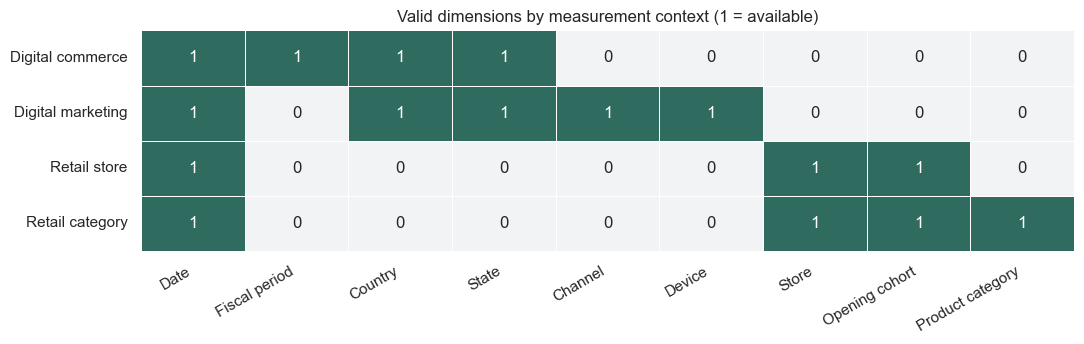

In [17]:
contexts = ["Digital commerce", "Digital marketing", "Retail store", "Retail category"]
dimensions = ["Date", "Fiscal period", "Country", "State", "Channel", "Device", "Store", "Opening cohort", "Product category"]
availability = pd.DataFrame(0, index=contexts, columns=dimensions, dtype=int)
availability.loc["Digital commerce", ["Date", "Fiscal period", "Country", "State"]] = 1
availability.loc["Digital marketing", ["Date", "Country", "State", "Channel", "Device"]] = 1
availability.loc["Retail store", ["Date", "Store", "Opening cohort"]] = 1
availability.loc["Retail category", ["Date", "Store", "Opening cohort", "Product category"]] = 1

fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(availability, annot=True, fmt="d", cmap=["#f1f3f5", "#2f6b5f"], cbar=False, linewidths=.5, ax=ax)
ax.set_title("Valid dimensions by measurement context (1 = available)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. What does “last week” mean?

Relative dates must be based on the latest complete period in the files, not today's date. The current-year rows include LY values alongside them, but they do not include actual prior-year dates.

In [18]:
# Find complete Monday–Sunday weeks across all four sources.
week_counts = []
for name in ["digital_commerce", "digital_marketing", "retail_store", "retail_category"]:
    df = frames[name]
    date = SOURCES[name]["date"]
    dates = pd.Series(pd.DatetimeIndex(df[date].unique()))
    counts = dates.groupby(dates.dt.to_period("W-SUN")).nunique()
    for period, count in counts.items():
        week_counts.append({
            "source": name,
            "week_start": period.start_time.date(),
            "week_end": period.end_time.date(),
            "distinct_dates": count,
            "complete": count == 7,
        })

week_completeness = pd.DataFrame(week_counts)
week_pivot = week_completeness.pivot(index=["week_start", "week_end"], columns="source", values="distinct_dates")
display(week_pivot)

common_complete = (
    week_completeness.groupby(["week_start", "week_end"])["complete"].all()
)
latest_week = common_complete[common_complete].index[-1]
previous_week = common_complete[common_complete].index[-2]
print(f"Proposed latest complete week: {latest_week[0]} to {latest_week[1]}")
print(f"Previous complete week:        {previous_week[0]} to {previous_week[1]}")

,source,digital_commerce,digital_marketing,retail_category,retail_store
week_start,week_end,,,,
2026-04-27,2026-05-03,1,1,1,1
2026-05-04,2026-05-10,7,7,7,7
2026-05-11,2026-05-17,7,7,7,7
2026-05-18,2026-05-24,7,7,7,7
2026-05-25,2026-05-31,7,7,7,7
2026-06-01,2026-06-07,7,7,7,7
2026-06-08,2026-06-14,7,7,7,7
2026-06-15,2026-06-21,7,7,7,7
2026-06-22,2026-06-28,7,7,7,7


Proposed latest complete week: 2026-06-22 to 2026-06-28
Previous complete week:        2026-06-15 to 2026-06-21


In [19]:
# Inspect the supplied fiscal mapping and test whether each current date has one mapping.
fiscal_map = (
    frames["digital_commerce"][["ty_order_date", "ty_fiscal_year", "ty_fiscal_month"]]
    .drop_duplicates()
    .sort_values("ty_order_date")
)
fiscal_ambiguity = fiscal_map.groupby("ty_order_date").size().max()
fiscal_boundaries = (
    fiscal_map.groupby(["ty_fiscal_year", "ty_fiscal_month"])["ty_order_date"]
    .agg(["min", "max", "nunique"])
)
display(fiscal_boundaries)
print(f"Maximum fiscal mappings per date: {fiscal_ambiguity}")

min        max  nunique
ty_fiscal_year ty_fiscal_month                               
2026           5               2026-05-03 2026-05-30       28
               6               2026-05-31 2026-07-04       35

Maximum fiscal mappings per date: 1


### Proposed date rules

- **Last week:** the latest complete Monday–Sunday week in the requested source. A cross-channel answer uses the latest week complete in all required sources.
- **Previous week:** the complete Monday–Sunday week immediately before it.
- **Current week:** label it as partial when fewer than seven days are present; compare it only with the same number of days from the previous week.
- **Latest seven days:** support this as a separate rolling period, but do not call it “last week.”
- **Year over year:** compare TY with the LY value supplied on the same row and call it the `provided LY comparator`; do not invent a 2025 date.
- **Last month:** use the latest complete calendar month until the company provides its official fiscal calendar.
- **Partial periods:** leave them out of full-period comparisons unless a user requests a matched period-to-date comparison.

## 9. How this becomes the app's data layer

The deployment database will contain one cleaned copy of each source rather than separate raw and fact copies. The original workbooks and reproducible ingestion script remain the raw record, while source-file and source-row fields preserve traceability inside SQLite.

| Object | Plain-language purpose |
|---|---|
| `fact_digital_commerce` | Digital commerce totals and geography |
| `fact_digital_marketing` | GA, channel, device, and session analysis |
| `fact_retail_store` | Retail performance and store ranking |
| `fact_retail_category` | Retain category data but block it from approved monetary metrics |
| `dim_date` | Shared Monday–Sunday weeks, calendar months, and supplied Digital fiscal mapping |
| `vw_*_metrics` | Consistent names, `Unknown` handling, quality flags, and paired LY measures |

The fact tables retain TY and paired LY measures as separate columns. This supports supplied comparisons without inventing prior-year dates and avoids doubling the deployment database with duplicate raw tables.

### Naming convention

SQLite and Python use lowercase `<context>_<metric>_<period>` names so similar measures cannot be confused. The interface uses shorter business labels.

| Metric ID | Stored columns | Display label |
|---|---|---|
| `digital_revenue` | `digital_revenue_ty`, `digital_revenue_ly` | Digital Revenue |
| `ga_revenue` | `ga_revenue_ty`, `ga_revenue_ly` | GA Revenue |
| `ga_orders` | `ga_orders_ty`, `ga_orders_ly` | GA Orders |
| `store_revenue` | `store_revenue_ty`, `store_revenue_ly` | Store Revenue |
| `store_orders` | `store_orders_ty`, `store_orders_ly` | Store Orders |

The period suffix stays at the end, and derived metrics follow the same context prefix, such as `ga_conversion_rate` and `store_aov`.

### What the LLM is allowed to request

The model can select a registered business context, metric, dimension, filter, period, comparison, sorting rule, and result limit. Python validates that combination and produces parameterized, read-only SQL. The model cannot submit arbitrary SQL.

The MVP exposes five tools:

| Tool | Purpose |
|---|---|
| `get_performance_summary` | Return approved KPIs for a context and comparison |
| `analyze_revenue_drivers` | Quantify the approved Digital or Retail revenue bridge |
| `rank_performance` | Rank a valid country, channel, device, or store dimension |
| `diagnose_stores` | Identify declining stores and the responsible operating driver |
| `forecast_metric` | Produce a simple short-term forecast with limitations |

### Proposed source ownership

| Business question | Source used |
|---|---|
| Digital top-line revenue, orders, units, customers, AOV, and UPT | Digital commerce |
| Channels, devices, tracked sessions, and marketing diagnostics | Digital marketing |
| Retail sales, traffic, orders, units, conversion, AOV, UPT, and store ranking | Retail store |
| Product-category monetary contribution | Blocked until category totals are explained |
| Combined Digital + Retail revenue | Blocked until currency and accounting definitions are confirmed |

## 10. Recommended contract and approval gate

### What we learned

1. The four files share a date range but represent four different analytical contexts, not one table that can be freely joined.
2. Digital commerce and Digital marketing need separate labels and responsibilities because their overlapping measures do not reconcile.
3. Retail category dollars should not be used in executive findings because they do not reconcile with store totals.
4. Unknown locations need honest labels, and the Retail `store_id = 0` records can be removed as confirmed placeholders.
5. The files contain eight complete Monday–Sunday weeks plus partial weeks at both edges. Their LY columns support comparison values, not reconstructed prior-year dates.
6. Most Retail rows with no LY activity belong to stores that were not open in the approximate LY period; these are expected new-store baselines rather than errors.

### Approval status

- **Approved:** four-source ownership model and reporting restrictions.
- **Approved:** Monday–Sunday weeks, matched partial-period comparisons, supplied LY comparators, and calendar-month fallback.
- **Approved:** handling of unknowns, placeholders, possible returns, and zero-LY baselines.
- **Approved:** four cleaned fact tables, one date dimension, and metric views without duplicate raw tables.
- **Approved:** context-first metric names and the five-tool agent contract.
